# Machine Learning Final Project

**Group Members:**
- Larissa Pereira Moraes ()
- Yousra Deghane ()
- Zainab Fatima ()


## The Biological Problem

Can we classify a healthy patient from a patient with Parkinson's disease based on the voice biomarkers.

- Input data: voice measurements

- Target variable: status 0 (healthy) and 1 (Parkinson's)

- One row represents: a voice recording

- One column represents: a feature

**Biological relevance:** Parkison's disease presents vocal alterations in the early to mid stages of the disease, making it a possible factor to detect using a machine learning model as a low-cost diagnostic method (Xiu et al., 2024).

### Setting up the environment

In [1]:
# setting up ML libraries

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

np.random.seed(42)

### Exploratory Analysis of the Dataset

In [3]:
# !pip install ucimlrepo
import sys
!{sys.executable} -m pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [7]:
from ucimlrepo import fetch_ucirepo as fetch_uci_dataset

In [20]:
# Dataset 5 - Parkinsons

parkinson = fetch_uci_dataset(id=174) # fetched data from UCI API

X_parkinson_raw = parkinson.data.features.copy()  # copy of all the features
y_parkinson_raw = parkinson.data.targets.copy()   # copy of all the samples' targets

# printing features and targets
print("Feature columns:")
print(X_parkinson_raw.columns.tolist())

print("\nTarget columns:")
print(y_parkinson_raw.columns.tolist())

# getting the target column as a 1D array to be used in sklearn
# iloc[:, 0] flattens the 2D array into a 1D series for sklearn's fit(X,y)
y_parkinson = y_parkinson_raw.iloc[:, 0].copy()

# Remove non-numeric if present: column "name" 
X_parkinson = X_parkinson_raw.select_dtypes(include="number").copy()

# compiling the X and y into a new Panda's dataframe
parkinson_data = pd.concat(
    [X_parkinson, pd.Series(y_parkinson, name="target")],
    axis=1
)

print("X shape:", X_parkinson.shape)
print("y shape:", y_parkinson.shape)
print("Target values:")
print(pd.Series(y_parkinson).value_counts())

display(parkinson_data.head())

Feature columns:
['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target columns:
['status']
X shape: (195, 22)
y shape: (195,)
Target values:
status
1    147
0     48
Name: count, dtype: int64


,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,target
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,1
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,1
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,1
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,1
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,1


### Check for NA or NaN

**Point 2.3**  
Check whether there are missing values. If yes, describe how you plan to
handle them.


In [17]:
parkinson_data.isna().sum()

MDVP:Fo         0
MDVP:Fhi        0
MDVP:Flo        0
MDVP:Jitter     0
MDVP:Jitter     0
MDVP:RAP        0
MDVP:PPQ        0
Jitter:DDP      0
MDVP:Shimmer    0
MDVP:Shimmer    0
Shimmer:APQ3    0
Shimmer:APQ5    0
MDVP:APQ        0
Shimmer:DDA     0
NHR             0
HNR             0
RPDE            0
DFA             0
spread1         0
spread2         0
D2              0
PPE             0
target          0
dtype: int64

In [18]:
parkinson_data.isnull().sum()

MDVP:Fo         0
MDVP:Fhi        0
MDVP:Flo        0
MDVP:Jitter     0
MDVP:Jitter     0
MDVP:RAP        0
MDVP:PPQ        0
Jitter:DDP      0
MDVP:Shimmer    0
MDVP:Shimmer    0
Shimmer:APQ3    0
Shimmer:APQ5    0
MDVP:APQ        0
Shimmer:DDA     0
NHR             0
HNR             0
RPDE            0
DFA             0
spread1         0
spread2         0
D2              0
PPE             0
target          0
dtype: int64

### Check Column Types

**Point 2.4**  
Check whether any column has a data type that is unexpected for its
role.

There are no columns with unexpected data types, they are all float64 and int 64 (for the target) making it appropriate for our model.

In [19]:
parkinson_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MDVP:Fo       195 non-null    float64
 1   MDVP:Fhi      195 non-null    float64
 2   MDVP:Flo      195 non-null    float64
 3   MDVP:Jitter   195 non-null    float64
 4   MDVP:Jitter   195 non-null    float64
 5   MDVP:RAP      195 non-null    float64
 6   MDVP:PPQ      195 non-null    float64
 7   Jitter:DDP    195 non-null    float64
 8   MDVP:Shimmer  195 non-null    float64
 9   MDVP:Shimmer  195 non-null    float64
 10  Shimmer:APQ3  195 non-null    float64
 11  Shimmer:APQ5  195 non-null    float64
 12  MDVP:APQ      195 non-null    float64
 13  Shimmer:DDA   195 non-null    float64
 14  NHR           195 non-null    float64
 15  HNR           195 non-null    float64
 16  RPDE          195 non-null    float64
 17  DFA           195 non-null    float64
 18  spread1       195 non-null    

Point 2.1
Report the number of samples and the number of variables.
- 195 voice recordings
- 22 feature variables

Point 2.2
Identify which columns are metadata, which columns are input features, and which column is the target.
- Metadata Columns: name (dropped)
- Input Features: MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz), MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP, MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA, NHR, HNR, RPDE, D2, DFA, spread1, spread2, PPE
- Target: status (1 = Parkinson's, 0 = healthy)


Point 2.3
Check whether there are missing values. If yes, describe how you plan to handle them.

There are no missing values in our dataset, we can proceed with the creation of the model.

Point 2.4
Check whether any column has a data type that is unexpected for its role.

Description of Columns in the Dataset:
- name - ASCII subject name and recording number [DROPPED]
- MDVP:Fo(Hz) - Average vocal fundamental frequency
- MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
- MDVP:Flo(Hz) - Minimum vocal fundamental frequency
- MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several 
measures of variation in fundamental frequency
- MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
- NHR,HNR - Two measures of ratio of noise to tonal components in the voice
- status - Health status of the subject (one) - Parkinson's, (zero) - healthy
- RPDE,D2 - Two nonlinear dynamical complexity measures
- DFA - Signal fractal scaling exponent
spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation

## Model Design: Binary Classification

**Target and Problem type:**
Since we are predicting whether a person has Parkinson's or not, our machine learning task follows a binary categorcal target.

**Compatible models:**
Binary classification

Models that are not appropriate and why:
- Regression: [why]
- Multiclass classification: [why]

## Baseline Template: logistic regression

Our data is unbalanced, with a ratio of 3:1 for Parkinson's vs. Healthy. In this case, as we are conducting logistic regression, we can use sklearn's parameter to penalize misclassifications of the minority class.

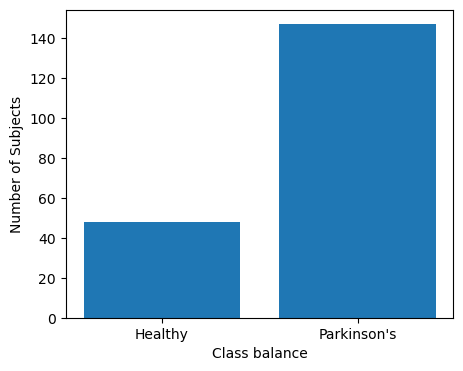

In [25]:
# Class Balance
labels = ["Healthy", "Parkinson's"]
counts = [np.sum(y_parkinson == 0), np.sum(y_parkinson == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of Subjects")
plt.xlabel("Class balance")
plt.show()

In [21]:
# --- Binary classification baseline: logistic regression ---


baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train, y_train)
y_val_pred = baseline_model.predict(X_val)

NameError: name 'X_train' is not defined

References

https://stats.stackexchange.com/questions/6067/does-an-unbalanced-sample-matter-when-doing-logistic-regression

https://www.sciencedirect.com/science/article/pii/S0892199724001681